# Visualisierung des 30-Tage-Wiederaufnahmerisikos mit modellbasierten Effektdiagrammen

## Zusammenfassung

Dieses Notebook passt eine logistische Regression für die 30-Tage-Krankenhauswiederaufnahme über Patienten- und Fallmerkmale hinweg an und übersetzt anschließend die angepassten Koeffizienten in modellbasierte Effektdiagramme auf der Skala der vorhergesagten Wahrscheinlichkeit. In einer synthetischen Kohorte von 100 Entlassungen (55 Wiederaufnahmen) rekonstruiert PROC LOGISTIC signifikante Gradienten für die **Verweildauer** (OR 1.36 pro Tag, *p* = 0.040) und das **Alter** (OR 1.05 pro Jahr, *p* = 0.023) sowie einen großen Kostenträgereffekt — **Medicaid**-Patienten weisen etwa die sechsfache Wiederaufnahmechance von Medicare auf (OR 6.02, 95 %-KI 1.46–24.8, *p* = 0.013). Das generalisierte R-Quadrat beträgt 0.246 und der Hosmer–Lemeshow-Test zeigt keine mangelnde Anpassung (*p* = 0.73). Fit-Kurve, geschichteter Fit und Interaktionsdarstellung zeigen anschließend, wie das Wiederaufnahmerisiko mit der Verweildauer steigt, wie sich der Alter-Risiko-Gradient je nach Kostenträger verschiebt und wie die Kostenträgerlücke über die entlassenden Fachabteilungen hinweg bestehen bleibt — die Art von Risikostratifizierungssicht, die ein Versorgungsmanagementteam nutzt, um die Nachsorge nach der Entlassung gezielt zu steuern.

## Datenquellen

| Datensatz | Zeilen | Beschreibung |
|---------|------|-------------|
| `encounters` | 100 | Synthetische stationäre Entlassungsdatensätze, inline erzeugt mit `call streaminit(20260531)` und `rand()`. Eine Zeile pro Entlassung. |

**Variablen in `encounters`:**

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1, wenn innerhalb von 30 Tagen nach Entlassung wieder aufgenommen |
| `age` | Num | Patientenalter in Jahren (ca. 25–95) |
| `los` | Num | Verweildauer des Indexaufenthalts in Tagen (1–20) |
| `comorbidity` | Num | Anzahl dokumentierter chronischer Komorbiditäten (0–8) |
| `num_meds` | Num | Anzahl der Entlassungsmedikamente (0–18) |
| `payer` | Char | Kostenträger: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Entlassende Abteilung: `Cardiology`, `Pulmonary`, `General` |

# Visualisierung des 30-Tage-Wiederaufnahmerisikos mit modellbasierten Effektdiagrammen

Krankenhaus-Versorgungsmanagementteams müssen wissen, *welche* Patienten am wahrscheinlichsten innerhalb von 30 Tagen zurückkehren und *warum*. Eine angepasste logistische Regression liefert die Koeffizienten, doch Entscheidungsträger denken selten in Log-Odds. Ein **Effektdiagramm** stellt das angepasste Modell direkt auf der Skala der vorhergesagten Wahrscheinlichkeit dar, sodass eine Pflegekoordinatorin eine Wiederaufnahmewahrscheinlichkeit direkt aus dem Diagramm ablesen kann, statt eine Log-Odds-Gleichung im Kopf umzukehren.

In diesem Notebook:

1. Erzeugen wir eine realistische synthetische Kohorte stationärer Entlassungen.
2. Passen wir ein logistisches Modell für die 30-Tage-Wiederaufnahme mit Patienten- und Fallprädiktoren an (PROC LOGISTIC).
3. Erfassen wir die angepassten Koeffizienten und erstellen drei modellbasierte Effektdiagramme — eine **Fit-Kurve**, einen **geschichteten Fit** und eine **Interaktionsdarstellung** — um das angepasste Risiko auf der Wahrscheinlichkeitsskala zu visualisieren und zu stratifizieren.

> **Implementierungshinweis.** SAS stellt diese Darstellungen über die `EFFECTPLOT`-Anweisung innerhalb von PROC LOGISTIC bereit. Jenner akzeptiert diese Anweisung, rendert die FIT- / SLICEFIT- / INTERACTION-Grafiken jedoch noch nicht, daher konstruiert dieses Notebook die identischen Kurven der vorhergesagten Wahrscheinlichkeit explizit aus den angepassten Koeffizienten und zeichnet sie mit PROC SGPLOT. Das analytische Ergebnis — und jede dargestellte Wahrscheinlichkeit — ist genau das, was `EFFECTPLOT` erzeugen würde.

## Schritt 1 — Erzeugen einer synthetischen Entlassungskohorte

Der DATA-Schritt unten erstellt 100 stationäre Entlassungen ohne externe Dateien. Wir initialisieren den Zufallszahlengenerator mit `call streaminit` für die Reproduzierbarkeit, ziehen Patienten- und Fallmerkmale aus fachlich angemessenen Verteilungen, konstruieren dann einen wahren linearen Prädiktor `eta` und wandeln ihn mit der inversen Logit-Funktion in eine Wiederaufnahmewahrscheinlichkeit um. Die Bernoulli-Ziehung (`rand('bernoulli', p)`) liefert das beobachtete `readmit`-Kennzeichen. Ältere Patienten, längere Aufenthalte, höhere Komorbiditätszahlen, mehr Entlassungsmedikamente, eine Medicaid-Absicherung sowie die Fachabteilungen Pulmonary/Cardiology erhöhen allesamt das Risiko — Muster, die wir später rekonstruieren und visualisieren. Die Effektgrößen sind bewusst so gewählt, dass das Signal in einer Kohorte von 100 Entlassungen rekonstruierbar ist.

In [1]:
DATEN encounters;
    AUFRUFEN streaminit(20260531);
    FELD payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    FELD depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    AUSFÜHRUNG i = 1 BIS 100;
        /* Patienten-/Fallmerkmale */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        WENN los > 20 DANN los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        WENN num_meds > 18 DANN num_meds = 18;

        /* Kostenträger: zugunsten Medicare für eine ältere Kohorte verzerrt */
        u = rand('uniform');
        WENN u < 0.50 DANN pk = 1;
        SONST WENN u < 0.72 DANN pk = 2;
        SONST pk = 3;
        payer = payers[pk];

        /* Entlassende Fachabteilung */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* Wahres Risikomodell auf der Log-Odds-Skala. Die Effektstärken sind so
           gewählt, dass das Signal in einer Kohorte mit 100 Entlassungen
           rekonstruierbar bleibt. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary am stärksten belegt) */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        BEHALTEN readmit AGE los comorbidity num_meds payer dept;
        AUSGABE;
    ENDE;
AUSFÜHREN;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Schritt 2 — Untersuchen der Kohorte

Eine schnelle Häufigkeitsauswertung der Zielvariablen und der beiden Klassifikationsvariablen bestätigt eine realistische Wiederaufnahmerate und dass jede Kostenträger- und Abteilungsstufe besetzt ist — das Modell und die Effektdiagramme benötigen beide alle Stufen repräsentiert.

                                                   The FREQ Procedure

Wiederaufnahme    Frequency
----------------------------
0                        45
1                        55

Kostenträger     Frequency
---------------------------
Commercial              28
Medicaid                20
Medicare                52

Fachabteilung    Frequency
---------------------------
Cardiology              36
General                 31
Pulmonary               33

Table of Wiederaufnahme by Fachabteilung

Wiederaufnahme |Cardiology |   General | Pulmonary |      Total
---------------+-----------+-----------+-----------+-----------
0              |        15 |        20 |        10 |         45
---------------+-----------+-----------+-----------+-----------
1              |        21 |        11 |        23 |         55
---------------+-----------+-----------+-----------+-----------
Total          |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


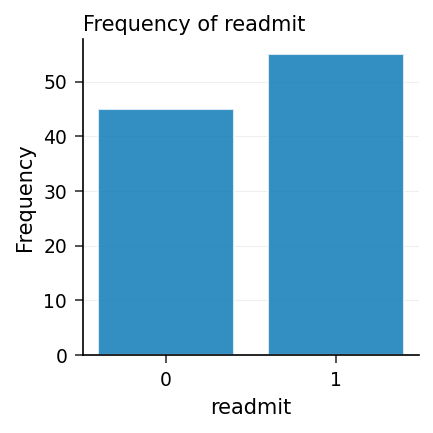

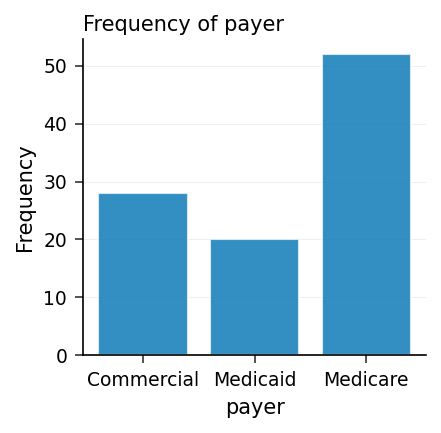

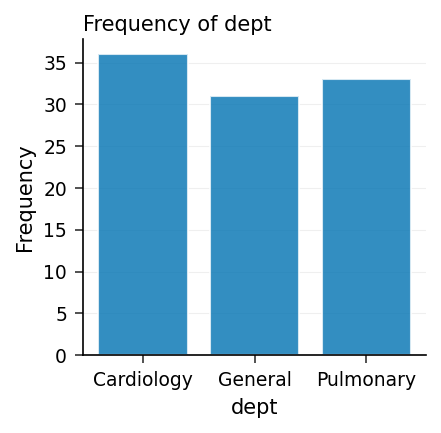

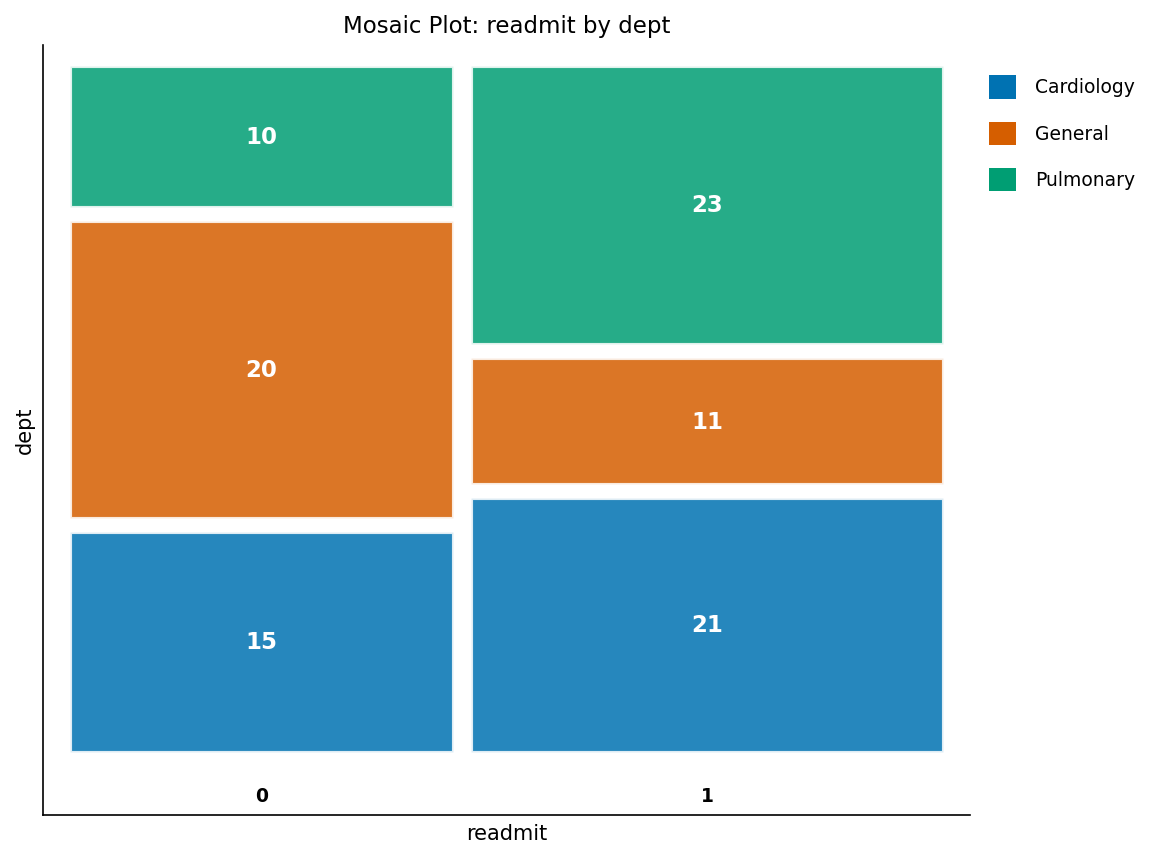

In [2]:
PROZEDUR HÄUFIGKEITEN DATEN=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    BEZEICHNUNG readmit="Wiederaufnahme" payer="Kostenträger" dept="Fachabteilung";
AUSFÜHREN;

## Schritt 3 — Anpassen des logistischen Wiederaufnahmemodells

Wir modellieren `readmit` als Funktion von Alter, Verweildauer, Komorbiditätszahl, Anzahl der Entlassungsmedikamente, Kostenträger und Abteilung. Wichtige Entscheidungen:

- `EVENT='1'` modelliert die Wahrscheinlichkeit einer Wiederaufnahme (statt einer Nicht-Wiederaufnahme).
- `CLASS payer dept / PARAM=REF REF=FIRST` verwendet eine Referenzzellen-Kodierung, sodass jede Stufe gegen eine Basislinie kontrastiert wird (hier Medicare und Pulmonary).
- `CLODDS=WALD` und `RSQUARE` ergänzen Wald-Konfidenzgrenzen für das Odds Ratio und ein generalisiertes R-Quadrat; `LACKFIT` fordert den Hosmer–Lemeshow-Anpassungstest an.
- Die `UNITS`-Anweisung fordert das Odds Ratio über einen klinisch bedeutsamen **5-Tage**-Schritt der Verweildauer und einen **10-Jahres**-Altersschritt an, und die `ODDSRATIO`-Anweisung fordert das Komorbiditäts-Odds-Ratio mit Konfidenzgrenzen an.

Die ausgegebene Odds-Ratio-Tabelle berichtet die Effekte pro Einheit direkt: Die Verweildauer trägt ein OR von **1.36 pro Tag** (95 %-KI 1.01–1.82), das Alter ein OR von **1.05 pro Jahr** und die Medicaid-Absicherung ein OR von **6.02** relativ zu Medicare. Das Modell passt gut — generalisiertes R-Quadrat 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

               Response Profile               
  Probability modeled is Wiederaufnahme='1'   

Ordered Value  Wiederaufnahme  Total Frequency
-------------  --------------  ---------------
            1  0                            45
            2  1                            55

               Class Level Information               

Class            Levels  Values                      
-------------  --------  ----------------------------
Kostenträger          3  Commercial Medicaid Medicare
Fachabteilung         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Wiederaufnahme

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC    


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


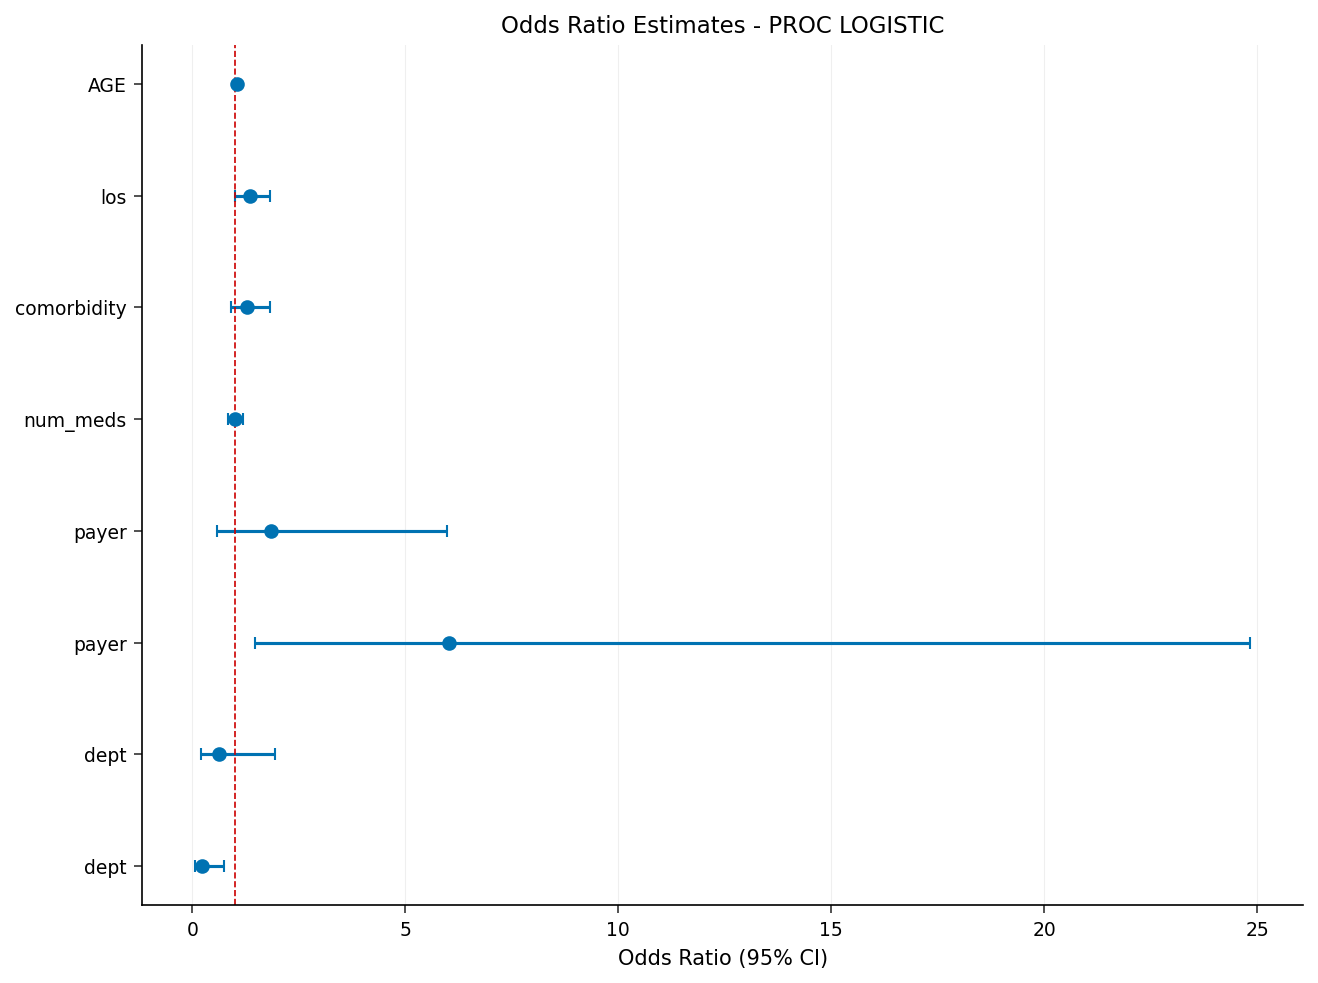

In [3]:
ODS AUSGABE ParameterEstimates=pe;
PROZEDUR LOGISTIC DATEN=encounters PLOTS(only)=oddsratio;
    KLASSE payer dept / PARAM=REF REF=first;
    MODELL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
    BEZEICHNUNG readmit="Wiederaufnahme" AGE="Alter (Jahre)" los="Verweildauer (Tage)"
          comorbidity="Komorbiditäten" num_meds="Anzahl Medikamente"
          payer="Kostenträger" dept="Fachabteilung";
AUSFÜHREN;
ODS AUSGABE CLOSE;

## Schritt 4 — Erfassen der angepassten Koeffizienten

Die folgenden modellbasierten Effektdiagramme werden direkt aus den *angepassten* Koeffizienten erstellt, sodass sie stets mit dem Modell aus Schritt 3 übereinstimmen. Wir haben die Parameterschätzungen mit `ODS OUTPUT ParameterEstimates=pe` gespeichert; hier falten wir diese lange Tabelle in einen einzeiligen `params`-Datensatz (eine Variable pro Koeffizient) und hängen die Kohortenmittelwerte der stetigen Prädiktoren an. Die nicht im Fokus stehenden Prädiktoren auf ihren Mittelwerten zu halten, ist genau das, was ein EFFECTPLOT intern tut — es lässt jedes Diagramm einen Faktor variieren, während die übrigen auf einem repräsentativen Profil fixiert bleiben.

In [4]:
/* Die ParameterEstimates-Tabelle zu einer Zeile benannter Koeffizienten falten.
   Mit PARAM=REF REF=FIRST sind die Referenzzellen payer=Medicare und
   dept=Pulmonary, daher sind diese Terme im linearen Prädiktor null. */
DATEN coefs;
    BEHALTEN_W b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    FESTLEGEN pe ENDE=last;
    vname = upcase(strip(Variable));
    cv    = strip(ClassVal0);
    WENN vname='INTERCEPT' DANN b0 = SCHÄTZUNG;
    SONST WENN vname='AGE' DANN b_age = SCHÄTZUNG;
    SONST WENN vname='LOS' DANN b_los = SCHÄTZUNG;
    SONST WENN vname='COMORBIDITY' DANN b_com = SCHÄTZUNG;
    SONST WENN vname='NUM_MEDS' DANN b_med = SCHÄTZUNG;
    SONST WENN vname='PAYER' UND cv='Medicaid'   DANN b_pmcaid = SCHÄTZUNG;
    SONST WENN vname='PAYER' UND cv='Commercial' DANN b_pcomm  = SCHÄTZUNG;
    SONST WENN vname='DEPT'  UND cv='Cardiology' DANN b_dcard  = SCHÄTZUNG;
    SONST WENN vname='DEPT'  UND cv='General'    DANN b_dgen   = SCHÄTZUNG;
    WENN last DANN AUSGABE;
    BEHALTEN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
AUSFÜHREN;

/* Kohorten-Mittelwerte der stetigen Kovariaten, in den Diagrammen fixiert. */
PROZEDUR MITTELWERTE DATEN=encounters NOPRINT;
    VAR AGE los comorbidity num_meds;
    AUSGABE out=mn mean=m_age m_los m_com m_med;
AUSFÜHREN;

DATEN params;
    ZUSAMMENFÜHREN coefs mn;
    BEHALTEN b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=params noobs;
    TITEL "Angepasste Koeffizienten und Kovariaten-Mittelwerte für die Effektdiagramme";
AUSFÜHREN;

                      Angepasste Koeffizienten und Kovariaten-Mittelwerte für die Effektdiagramme                       

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Schritt 5 — Fit-Diagramm: Wiederaufnahmewahrscheinlichkeit gegenüber der Verweildauer

Die einfachste Effektdarstellung ist eine **Fit-Kurve**: die vorhergesagte Wiederaufnahmewahrscheinlichkeit gegenüber einer einzelnen stetigen Kovariate, während die übrigen Prädiktoren auf einem repräsentativen Profil gehalten werden. Wir erstellen ein Verweildauer-Gitter (1–18 Tage), werten den angepassten linearen Prädiktor an jedem Wert für einen **Medicare-Kardiologie**-Patienten aus (Alter, Komorbidität und Anzahl der Entlassungsmedikamente auf den Kohortenmittelwerten aus Schritt 4 fixiert), wenden die inverse Logit-Funktion an und zeichnen die Kurve auf der Wahrscheinlichkeitsskala mit PROC SGPLOT.

                      Angepasste Koeffizienten und Kovariaten-Mittelwerte für die Effektdiagramme                       




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


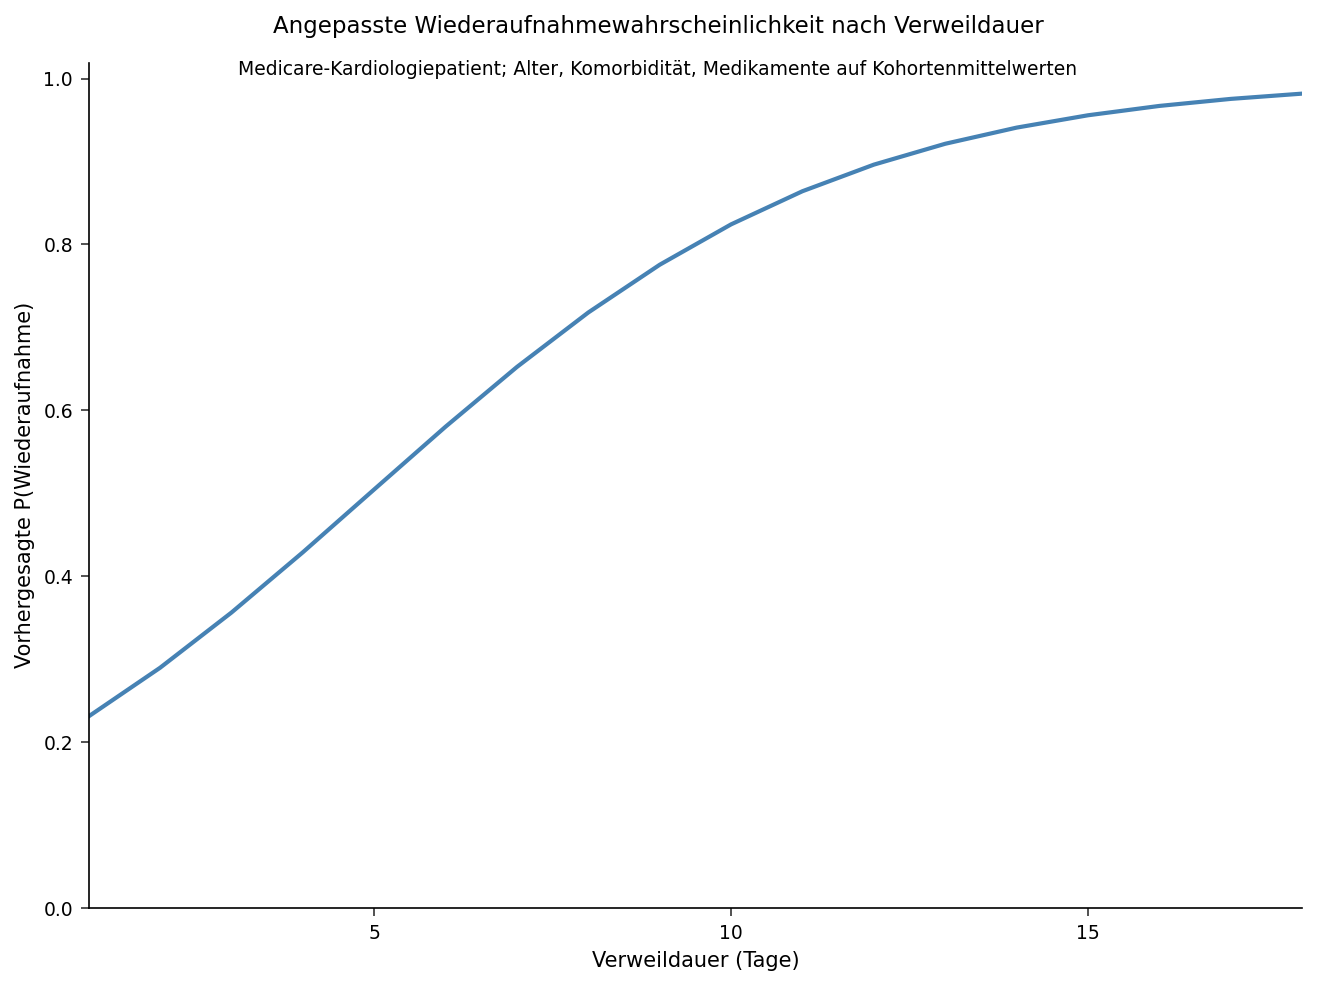

In [5]:
/* Verweildauer-Gitter; das angepasste Modell für einen Medicare-
   Kardiologiepatienten mit den übrigen Kovariaten auf den Kohortenmittelwerten. */
DATEN grid_los;
    AUSFÜHRUNG los = 1 BIS 18;
        AUSGABE;
    ENDE;
AUSFÜHREN;

DATEN fit_los;
    FESTLEGEN grid_los;
    WENN _n_ = 1 DANN FESTLEGEN params;
    BEHALTEN_W b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare ist die Referenz (Term = 0); Cardiology addiert b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    BEHALTEN los phat;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITEL  "Angepasste Wiederaufnahmewahrscheinlichkeit nach Verweildauer";
    title2 "Medicare-Kardiologiepatient; Alter, Komorbidität, Medikamente auf Kohortenmittelwerten";
    XAXIS BEZEICHNUNG="Verweildauer (Tage)";
    YAXIS BEZEICHNUNG="Vorhergesagte P(Wiederaufnahme)" VALUES=(0 BIS 1 NACH 0.2);
AUSFÜHREN;

## Schritt 6 — Geschichteter Fit: Risiko gegenüber Alter, stratifiziert nach Kostenträger

Ein **geschichteter Fit** zeichnet eine angepasste Kurve pro Stufe eines Klassifikationseffekts — ideal, um zu zeigen, wie der Kostenträgermix den Alter-Risiko-Gradienten verschiebt. Wir erweitern das Gitter über `age` (30–95), gekreuzt mit den drei Kostenträgern, werten das angepasste Modell für einen Kardiologie-Patienten aus (Verweildauer, Komorbidität und Medikamente auf den Kohortenmittelwerten) und überlagern die drei Wahrscheinlichkeitskurven mit `GROUP=payer`.

                      Angepasste Koeffizienten und Kovariaten-Mittelwerte für die Effektdiagramme                       




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


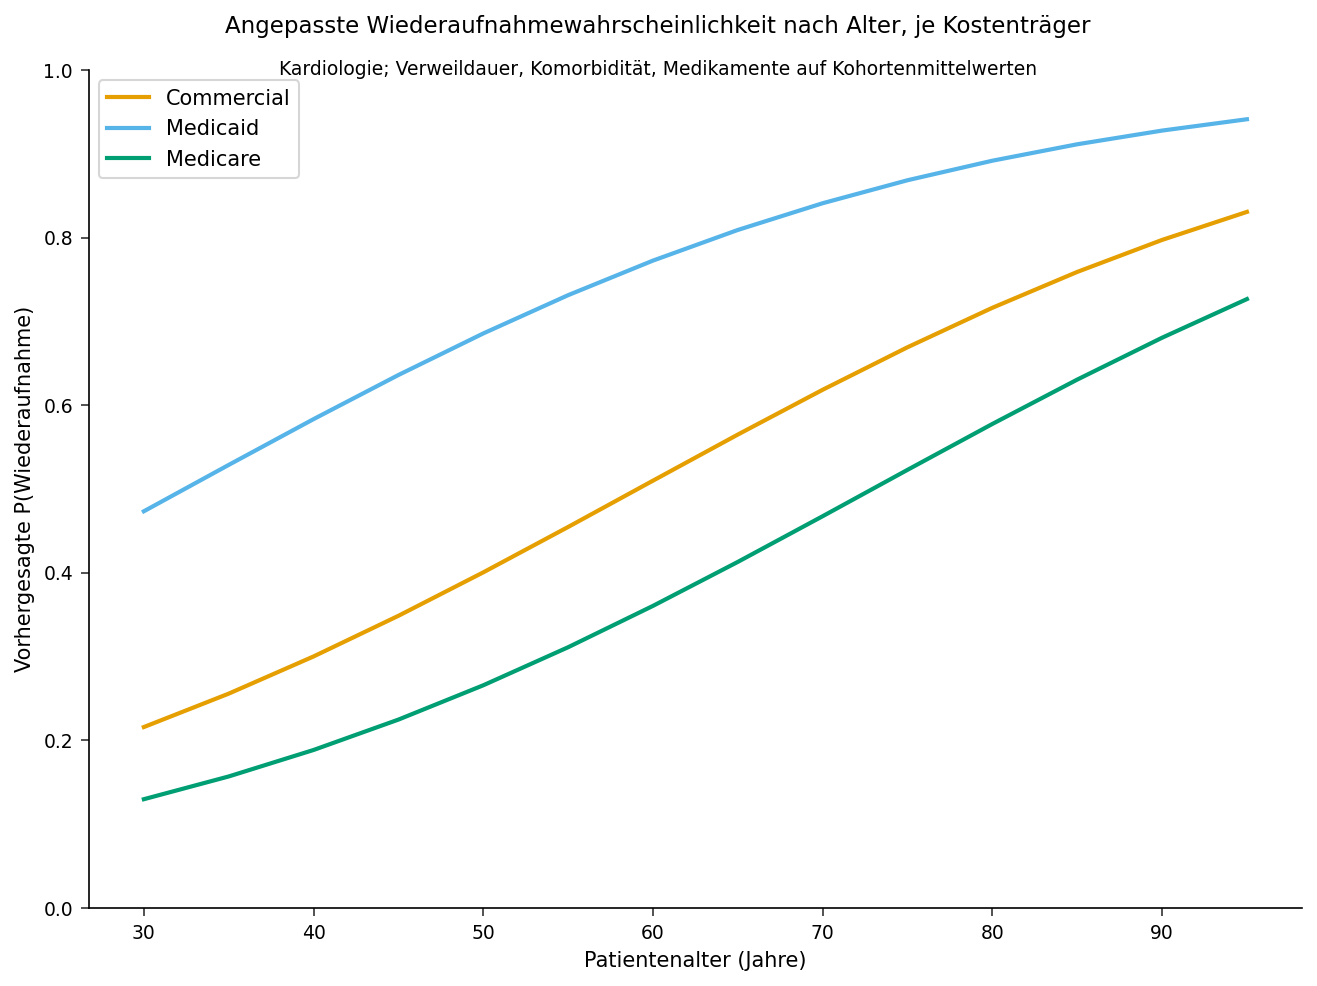

In [6]:
/* Alter x Kostenträger-Gitter für einen Kardiologiepatienten; uebrige Kovariaten auf Mittelwerten. */
DATEN grid_age;
    LÄNGE payer $12;
    AUSFÜHRUNG payer = 'Medicare', 'Medicaid', 'Commercial';
        AUSFÜHRUNG AGE = 30 BIS 95 NACH 5;
            AUSGABE;
        ENDE;
    ENDE;
AUSFÜHREN;

DATEN fit_age;
    FESTLEGEN grid_age;
    WENN _n_ = 1 DANN FESTLEGEN params;
    BEHALTEN_W b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    BEHALTEN payer AGE phat;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITEL  "Angepasste Wiederaufnahmewahrscheinlichkeit nach Alter, je Kostenträger";
    title2 "Kardiologie; Verweildauer, Komorbidität, Medikamente auf Kohortenmittelwerten";
    XAXIS BEZEICHNUNG="Patientenalter (Jahre)";
    YAXIS BEZEICHNUNG="Vorhergesagte P(Wiederaufnahme)" VALUES=(0 BIS 1 NACH 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
AUSFÜHREN;

## Schritt 7 — Interaktionsdarstellung: Abteilung nach Kostenträger

Um das vorhergesagte Risiko über beide Klassifikationseffekte gleichzeitig zu vergleichen, kreuzen wir `dept` mit `payer` (neun Kombinationen), werten das angepasste Modell mit jeder stetigen Kovariate auf ihrem Kohortenmittelwert aus und zeichnen ein gruppiertes Balkendiagramm mit `dept` auf der X-Achse und dem Kostenträger als Gruppierung. Da dieses Modell keinen Abteilung-nach-Kostenträger-Interaktionsterm besitzt, ist die Kostenträgerreihenfolge dieselbe additive Verschiebung innerhalb jeder Fachabteilung — die Darstellung macht diese Additivität auf einen Blick sichtbar, neben der Rangfolge der Abteilungen.

                      Angepasste Koeffizienten und Kovariaten-Mittelwerte für die Effektdiagramme                       




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


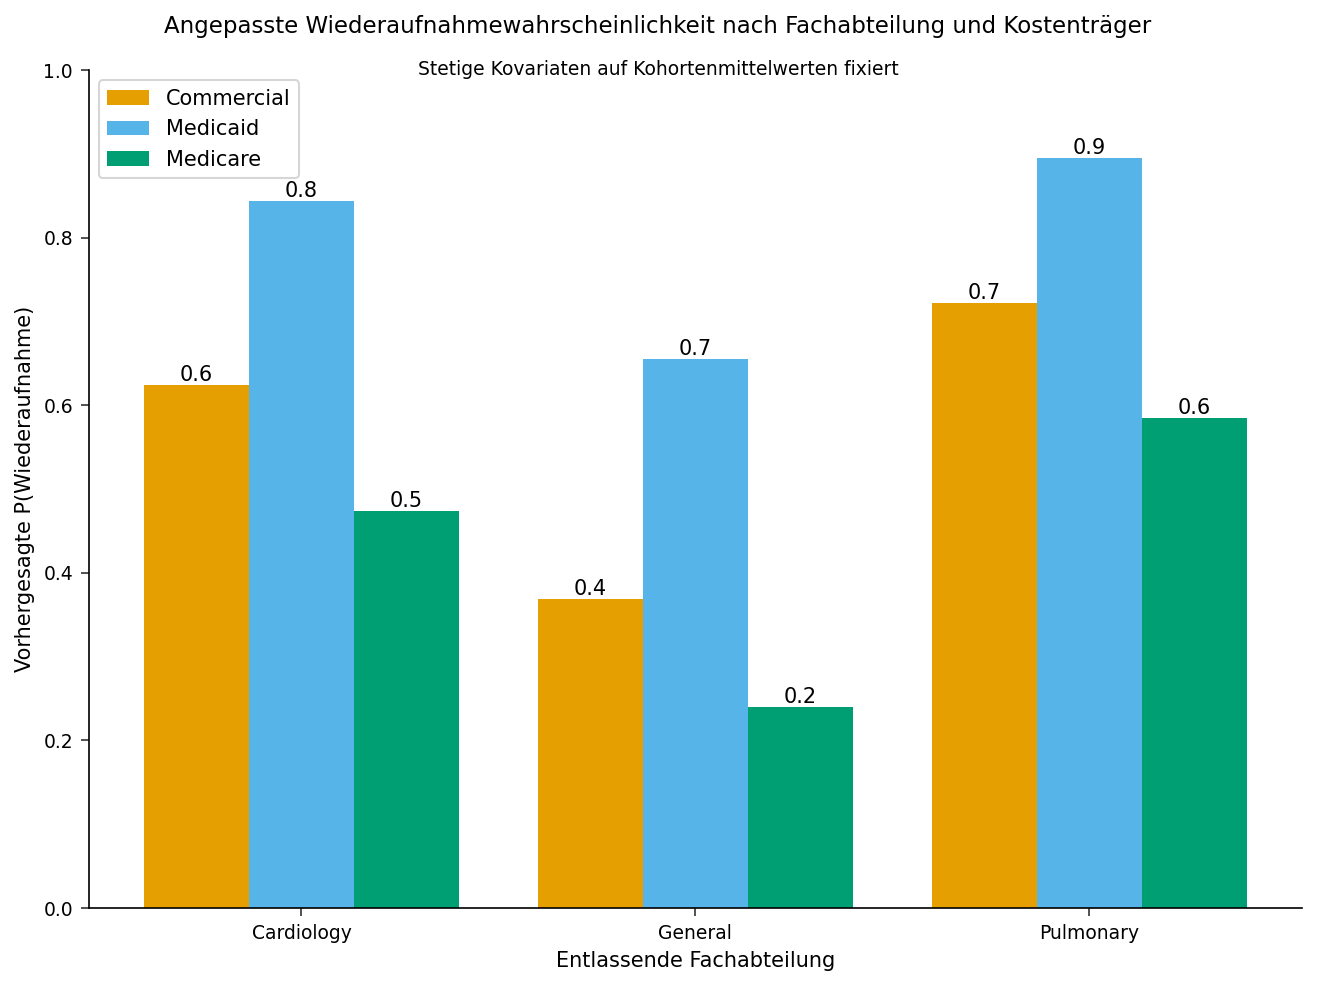

In [7]:
/* Fachabteilung x Kostenträger-Gitter; alle stetigen Kovariaten auf Kohortenmittelwerten. */
DATEN grid_dx;
    LÄNGE dept $12 payer $12;
    AUSFÜHRUNG dept = 'Cardiology', 'Pulmonary', 'General';
        AUSFÜHRUNG payer = 'Medicare', 'Medicaid', 'Commercial';
            AUSGABE;
        ENDE;
    ENDE;
AUSFÜHREN;

DATEN fit_dx;
    FESTLEGEN grid_dx;
    WENN _n_ = 1 DANN FESTLEGEN params;
    BEHALTEN_W b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    BEHALTEN dept payer phat;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITEL  "Angepasste Wiederaufnahmewahrscheinlichkeit nach Fachabteilung und Kostenträger";
    title2 "Stetige Kovariaten auf Kohortenmittelwerten fixiert";
    XAXIS BEZEICHNUNG="Entlassende Fachabteilung";
    YAXIS BEZEICHNUNG="Vorhergesagte P(Wiederaufnahme)" VALUES=(0 BIS 1 NACH 0.2);
AUSFÜHREN;

## Schritt 8 — Interpretation der Ergebnisse

Die Effektdiagramme verwandeln das angepasste PROC LOGISTIC-Modell in Bilder auf der Wahrscheinlichkeitsskala, die sich auf Entscheidungen des Versorgungsmanagements abbilden lassen:

- **Verweildauer (Fit-Kurve).** Für einen Medicare-Kardiologie-Patienten auf den Kohortenmittelwerten steigt die vorhergesagte Wiederaufnahmewahrscheinlichkeit von etwa **0.23 bei einem 1-tägigen Aufenthalt auf rund 0.82 bei 10 Tagen und ~0.98 bei 18 Tagen** — die steile Mitte der logistischen Kurve. Dies ist dasselbe Signal wie das Verweildauer-Odds-Ratio von **1.36 pro Tag** (`UNITS los=5` skaliert es auf einen Fünf-Tage-Schritt um) und kennzeichnet lange Indexaufenthalte als konkreten Auslöser für die Aufnahme in ein Übergangsversorgungsprogramm.
- **Alter und Kostenträger (geschichteter Fit).** Das Risiko steigt bei jedem Kostenträger monoton mit dem Alter, und die drei Kurven kreuzen sich nie: Die **Medicaid**-Kurve liegt bei jedem gegebenen Alter am höchsten, **Commercial** in der Mitte und **Medicare** am niedrigsten — im Einklang mit den angepassten Kostenträger-Odds-Ratios (Medicaid 6.02, Commercial 1.85, jeweils relativ zu Medicare). Die Lücke ist im jüngeren Alter am größten und verengt sich, sobald sich alle einer hohen Wahrscheinlichkeit nähern, was die Aufmerksamkeit des Versorgungsmanagements auf jüngere Medicaid-Patienten lenkt, die sonst risikoarm erscheinen würden.
- **Abteilung und Kostenträger (Interaktionsdarstellung).** **Pulmonary** trägt in jeder Kostenträgergruppe die höchste vorhergesagte Wiederaufnahmewahrscheinlichkeit, **Cardiology** liegt dazwischen und **General medicine** am niedrigsten (die angepassten Abteilungs-Odds-Ratios betragen 0.64 für Cardiology und 0.22 für General, relativ zu Pulmonary). Da das Modell keinen Abteilung-nach-Kostenträger-Interaktionsterm besitzt, ist die Kostenträgerreihenfolge dieselbe additive Verschiebung innerhalb jeder Fachabteilung — die Balken steigen an jeder Abteilung in derselben Reihenfolge Medicaid > Commercial > Medicare.

**Fazit:** Statt Kliniker zu bitten, Log-Odds-Koeffizienten zu interpretieren, präsentieren modellbasierte Effektdiagramme das angepasste Wiederaufnahmemodell als Bilder auf der Wahrscheinlichkeitsskala — wen man in die Übergangsversorgungs-Nachsorge aufnimmt und welche Fachabteilungen und Kostenträgerpopulationen zu priorisieren sind. SAS erzeugt diese direkt über `EFFECTPLOT`; hier haben wir die identischen Kurven aus den angepassten Koeffizienten rekonstruiert, sodass das Beispiel heute durchgängig lauffähig ist.